# Create 2D Plot 

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

## Functions and Definitions

In [2]:
#the function plots a t-I UV/Vis spectrum at a defined wavelength

def plot_intensity(folder_path, at_wavelength): 

    folder = Path(folder_path) 

    intensity_list = [] #every intensity at defined wavelength will be stored here

    #find out flow speed based on folder name:
    speed = "" 
    for ch in folder.name:
        if ch.isdigit():
            speed = speed + ch

    #generate list of all intensities in the folder at defined wavelength
    for file in sorted(folder.glob("*.txt")):

        data = pd.read_csv(file, skiprows=5, sep=";")

        #parameters:
        wavelength = data.iloc[1:,0].str.replace(",", ".").astype(float)
        intensity = data.iloc[1:,1].str.replace(",", ".").astype(float)

        idx = (wavelength - at_wavelength).abs().idxmin() #searches for wavelength index

        intensity_list.append(intensity.iloc[idx]) #adds intensity of defined wavelength to "intensity_list" 
    

    intensity_list = intensity_list / max(intensity_list) #normalization

    #plot:
    plt.plot(intensity_list)
    plt.xlabel("Time [s]")
    plt.ylabel("Intensity [a.u.]")

    baseline = np.mean(intensity_list[0: (len(intensity_list)//10) ]) #the baseline is defined as the average value of all intensities in the first tenth of the total time
    plt.axhline(y=baseline, linestyle="--", color = 'r', label="Baseline")

    font = {'family':'arial','color':'black','size':15}

    plt.title(f"UV/Vis 2D Plot, wavelength: {at_wavelength} nm, flow speed: {speed} ml/min", fontdict = font)

    plt.show()

## Examples

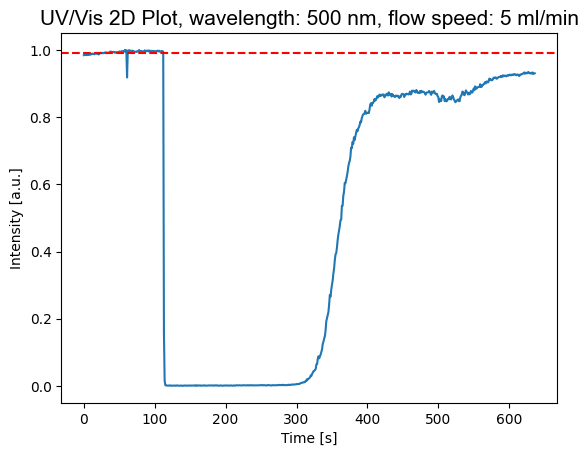

In [ ]:
#plot spectrum of spectroscopy test series with fluorescein concentration of 5 M at 500 nm:
path = "../data/test_series_spectroscopy/spectroscopy_fluorescein_5"
plot_intensity(path, 500)